## ⚡ Constructive Heuristics

**Concepts:** [Constructive heuristics](../routers.md#constructive-heuristics) · [Optimization approaches](../routers.md#optimization-approaches) **Network/Router API:** [⚡ EWRouter](hi20_heuristic.ipynb)

[constructor()](../autoapi/optiwindnet/heuristics/index.rst#optiwindnet.heuristics.constructor) is the unified constructive heuristics entry point. The available `method` values and what distinguishes them are listed in [Constructive heuristics](../routers.md#constructive-heuristics).

This notebook compares a few constructor settings on the same location and then converts the topology **S** into routed graphs **G** using [PathFinder](../autoapi/optiwindnet/pathfinding/index.rst#optiwindnet.pathfinding.PathFinder).

> Note: Removed heuristic entry points `EW_presolver`, `CPEW`, `OBEW`, and `NBEW` are mentioned here as a reference (removed in version 0.3.0 – migration guide in [Removed Heuristics](lo90_removed_heuristics.ipynb)).

In [1]:
from optiwindnet.importer import load_repository
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.pathfinding import PathFinder
from optiwindnet.heuristics import constructor
from optiwindnet.interarraylib import G_from_S
from optiwindnet.svg import svgplot

In [2]:
locations = load_repository()

### Simple example

Load Hollandse Kust Zuid

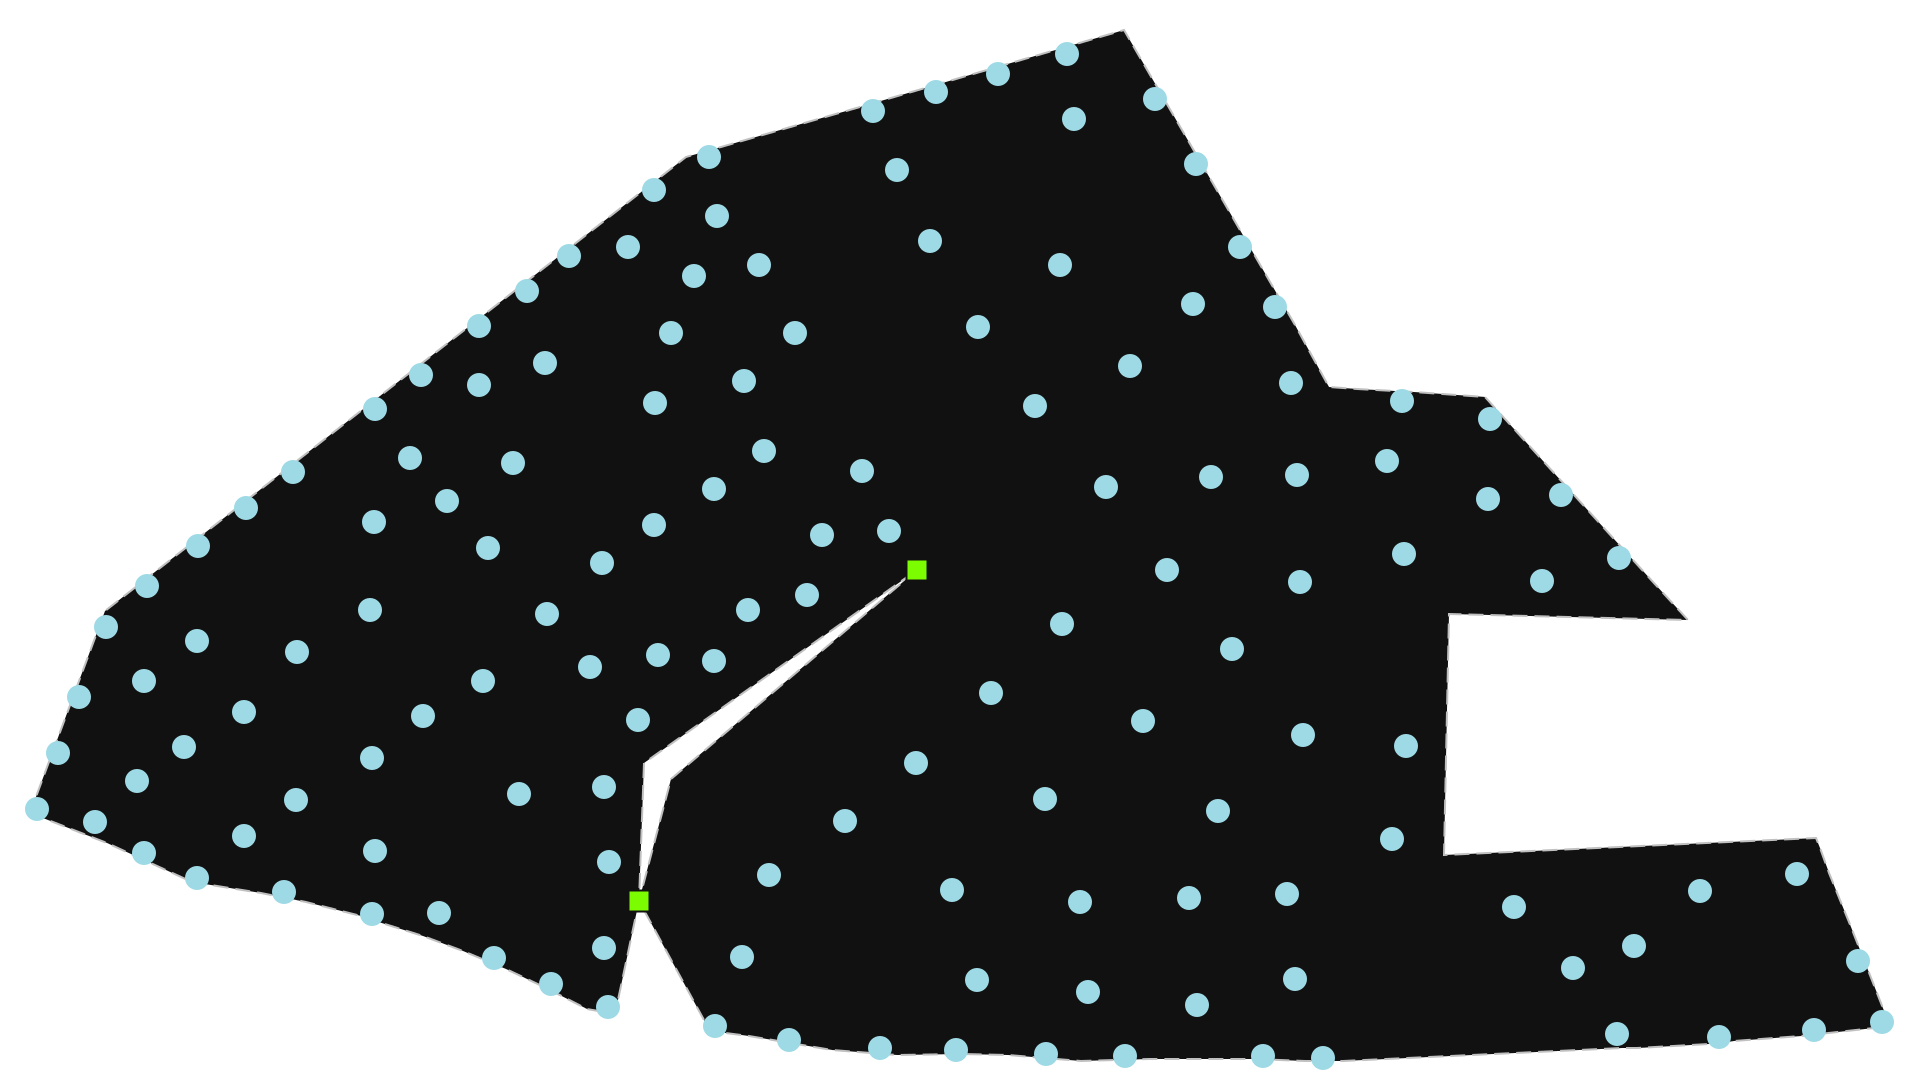

In [3]:
L = locations.kustzuid
svgplot(L)

Optimize Hollandse Kust Zuid

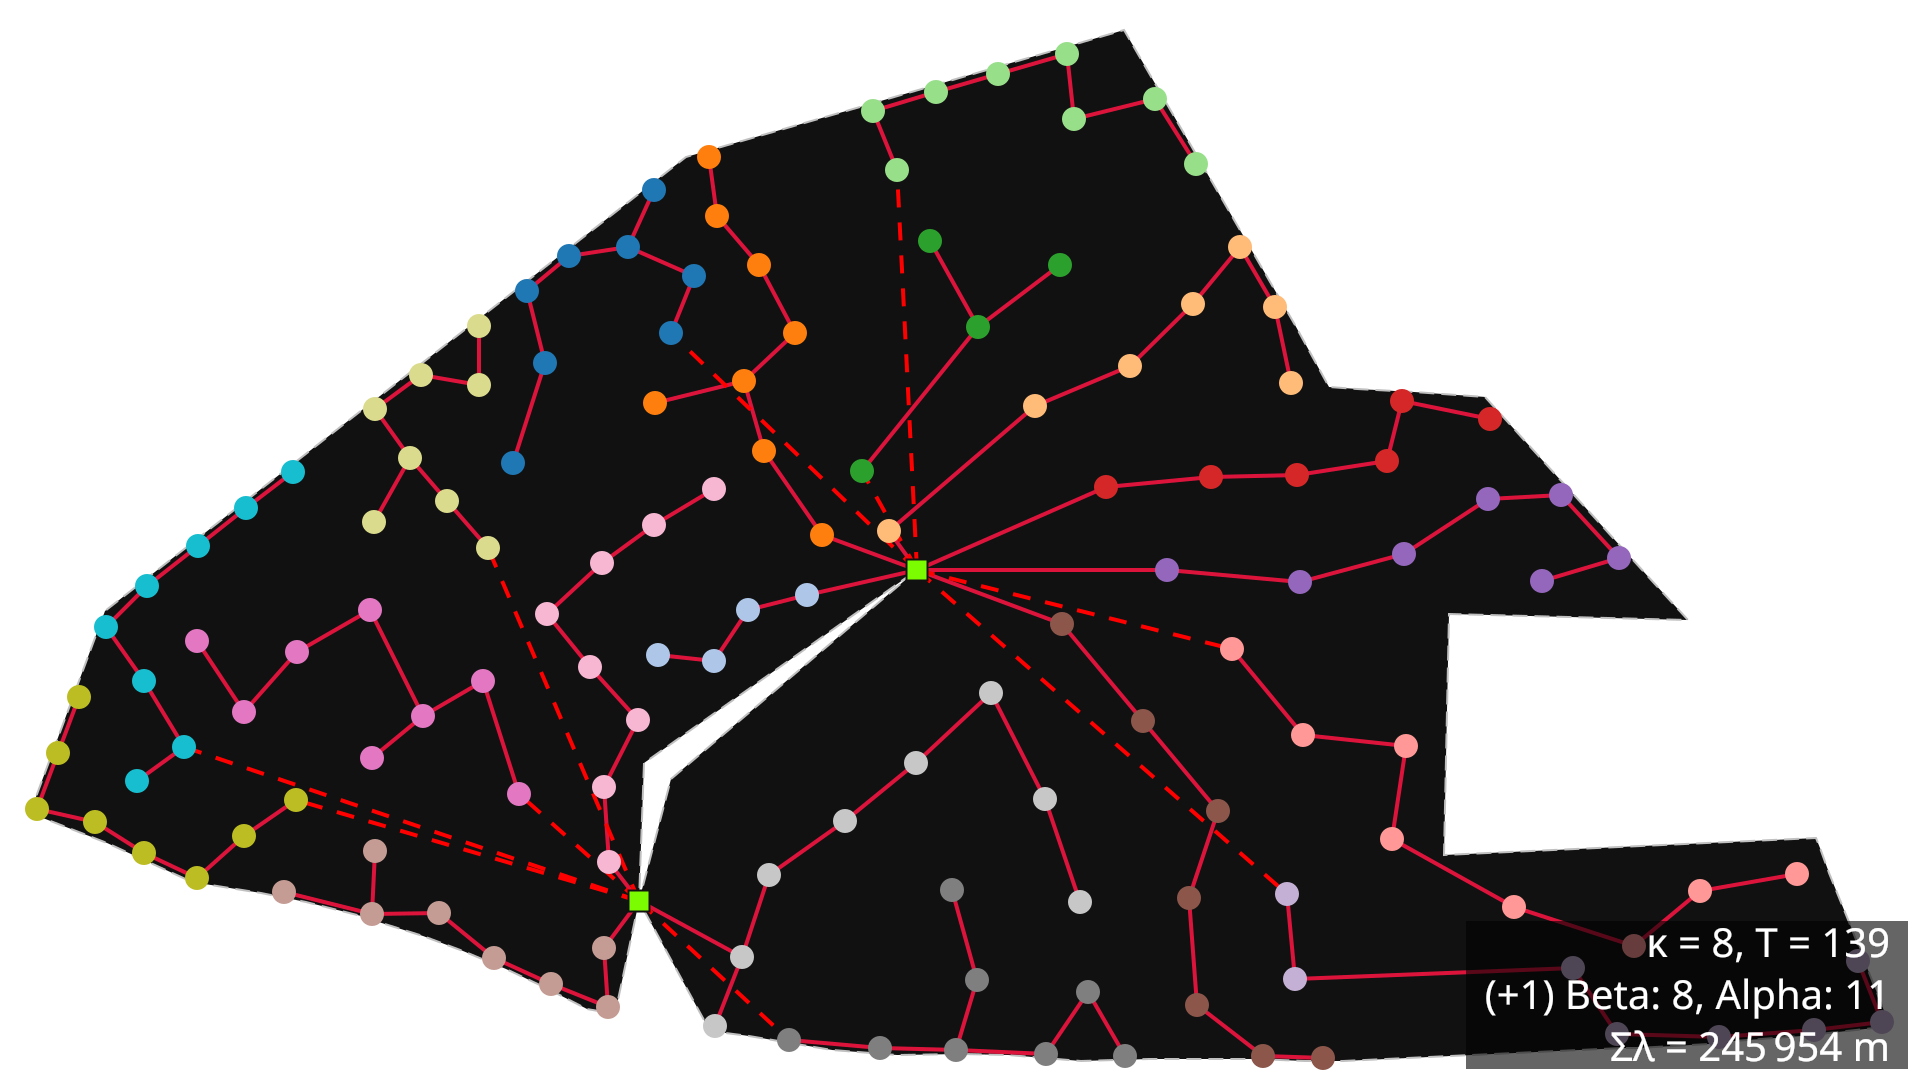

In [4]:
P, A = make_planar_embedding(L)
S = constructor(A, capacity=8)
G_tent = G_from_S(S, A)
svgplot(G_tent)

Route the feeders so as to avoid crossings

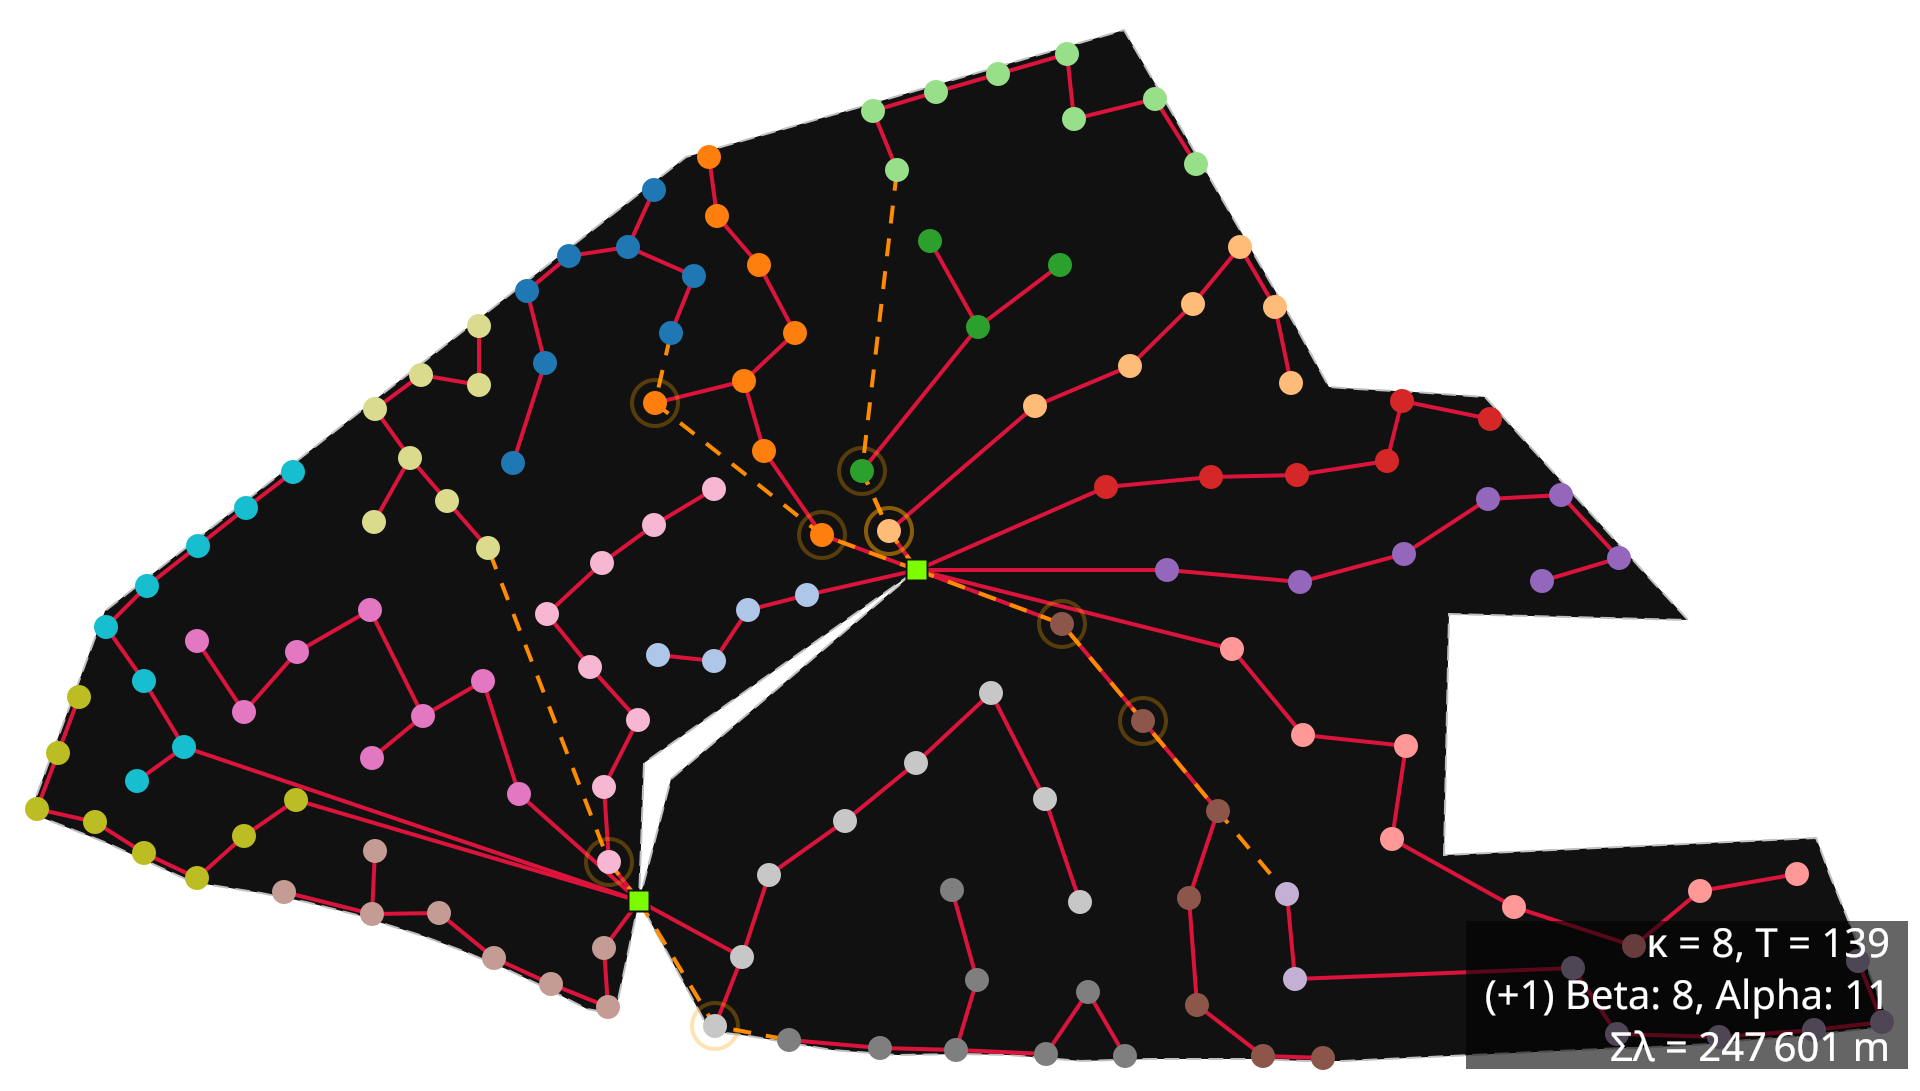

In [5]:
H = PathFinder(G_tent, P, A).create_detours()
svgplot(H)

### Constructor methods and parameters

Load Merkur

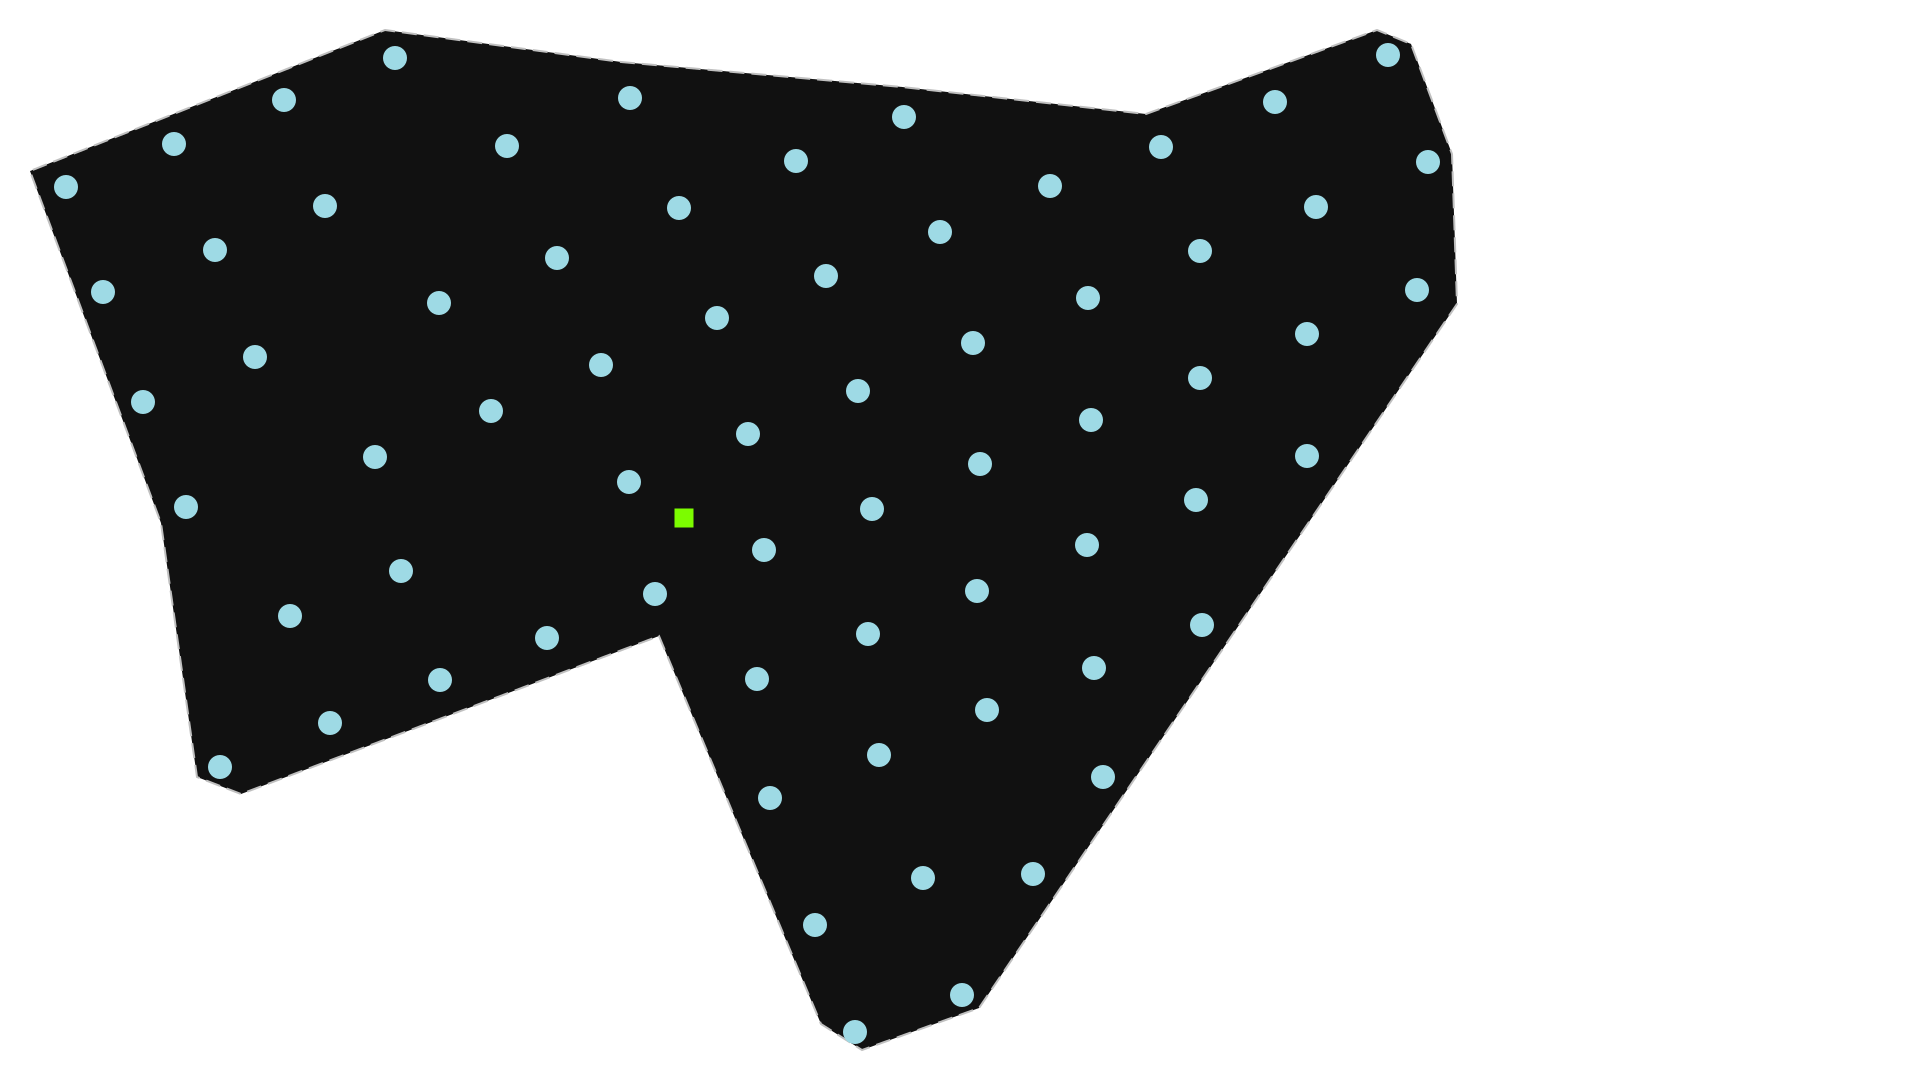

In [6]:
L = locations.merkur
svgplot(L)

Compare solutions obtained with different arguments

In [7]:
P, A = make_planar_embedding(L)
capacity = 9

settings = {
    'default rootlust': {},
    'rootlust (OBEW rootlust style)': {
        'method': 'rootlust',
        # matching OBEW's rootlust is capacity-dependent
        'rootlust_': (0.0, 0.6 * (capacity - 1) / capacity),  
    },
    'EW presolver style': {
        'method': 'biased_EW',
        'weigh_detours': False,
    },
    'biased_EW (OBEW style)': {
        'method': 'biased_EW',
        # straight_feeder_route=False,
        # weigh_detours=True,
    },
    'straight feeders (CPEW style)': {
        'method': 'biased_EW',
        'straight_feeder_route': True,
        'weigh_detours': False,
    },
    'radial (NBEW style)': {
        'method': 'radial_EW',
        'straight_feeder_route': True,
        'weigh_detours': False,
    },
    'radial (segmented feeders)': {
        'method': 'radial_EW',
        # straight_feeder_route=False,
        # weigh_detours=True,
    },
    # 'ringed' grows radial-style simple paths and closes each into a ring: both
    # endpoints connect to the same root (two feeders) joined at a zero-load link.
    # `capacity` is the per-arm limit, so here each ring holds up to 2*9 = 18.
    'ringed (closed loops)': {
        'method': 'ringed',
    },
}

In [8]:
solutions = {}
for label, kwargs in settings.items():
    S = constructor(A, capacity=capacity, **kwargs)
    G_tent = G_from_S(S, A)
    # PathFinder reroutes within the topology S declares (constructor labels
    # 'ringed' subtrees as closed loops, the other methods as trees)
    G = PathFinder(G_tent, planar=P, A=A).create_detours()
    solutions[label] = G

Visualize the variants

default rootlust


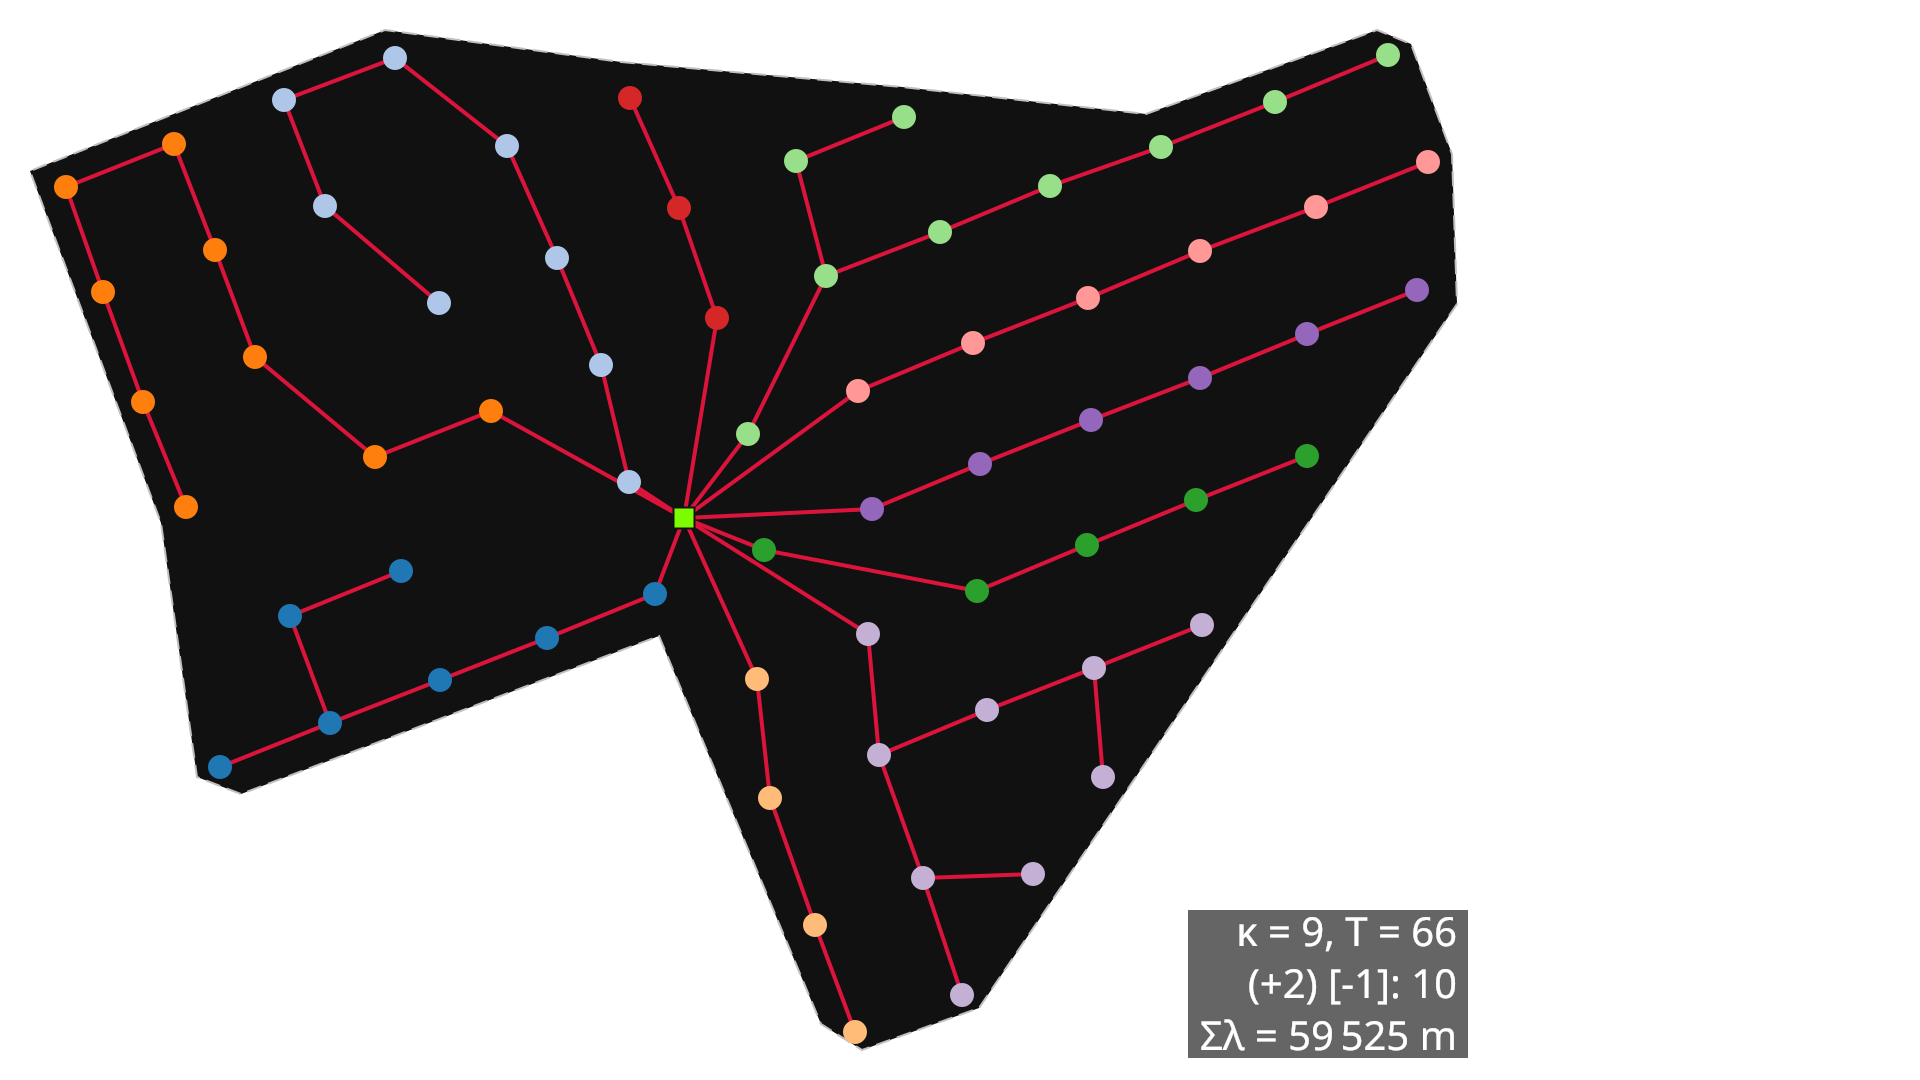

rootlust (OBEW rootlust style)


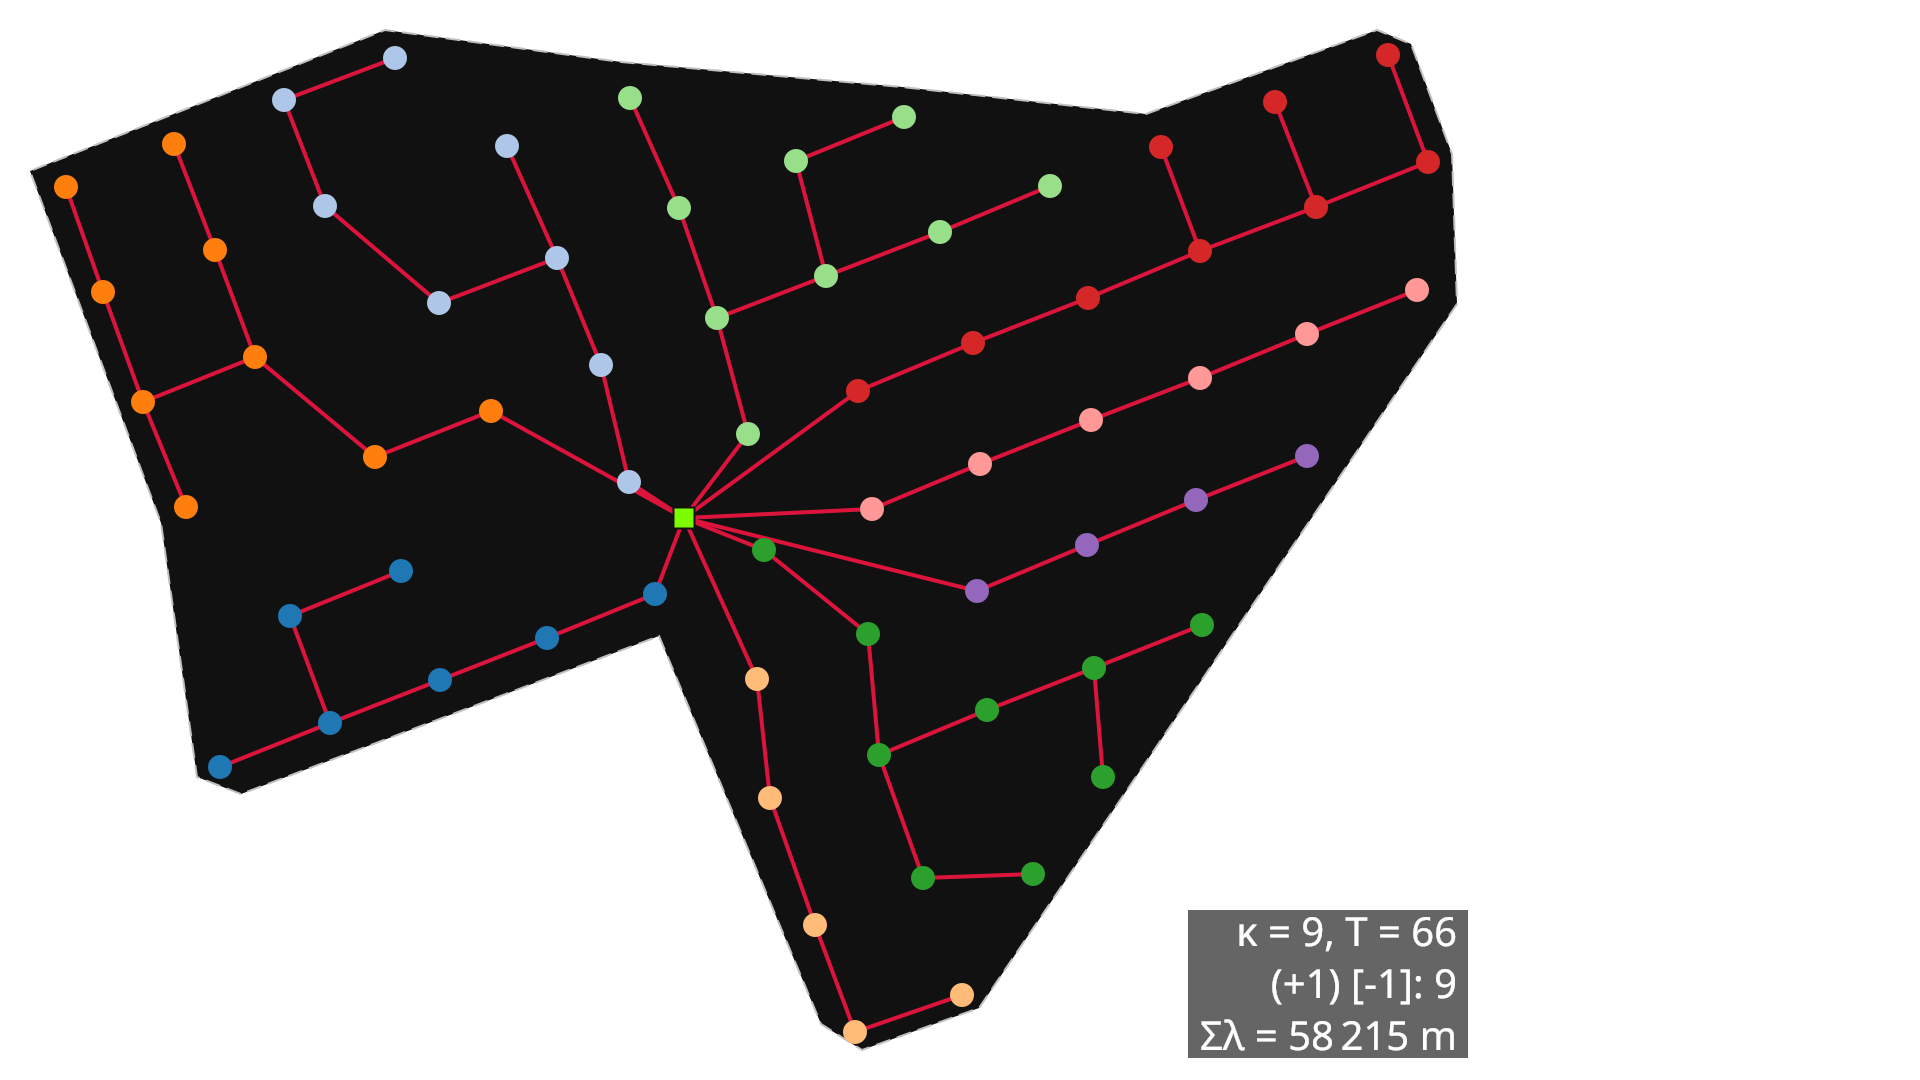

EW presolver style


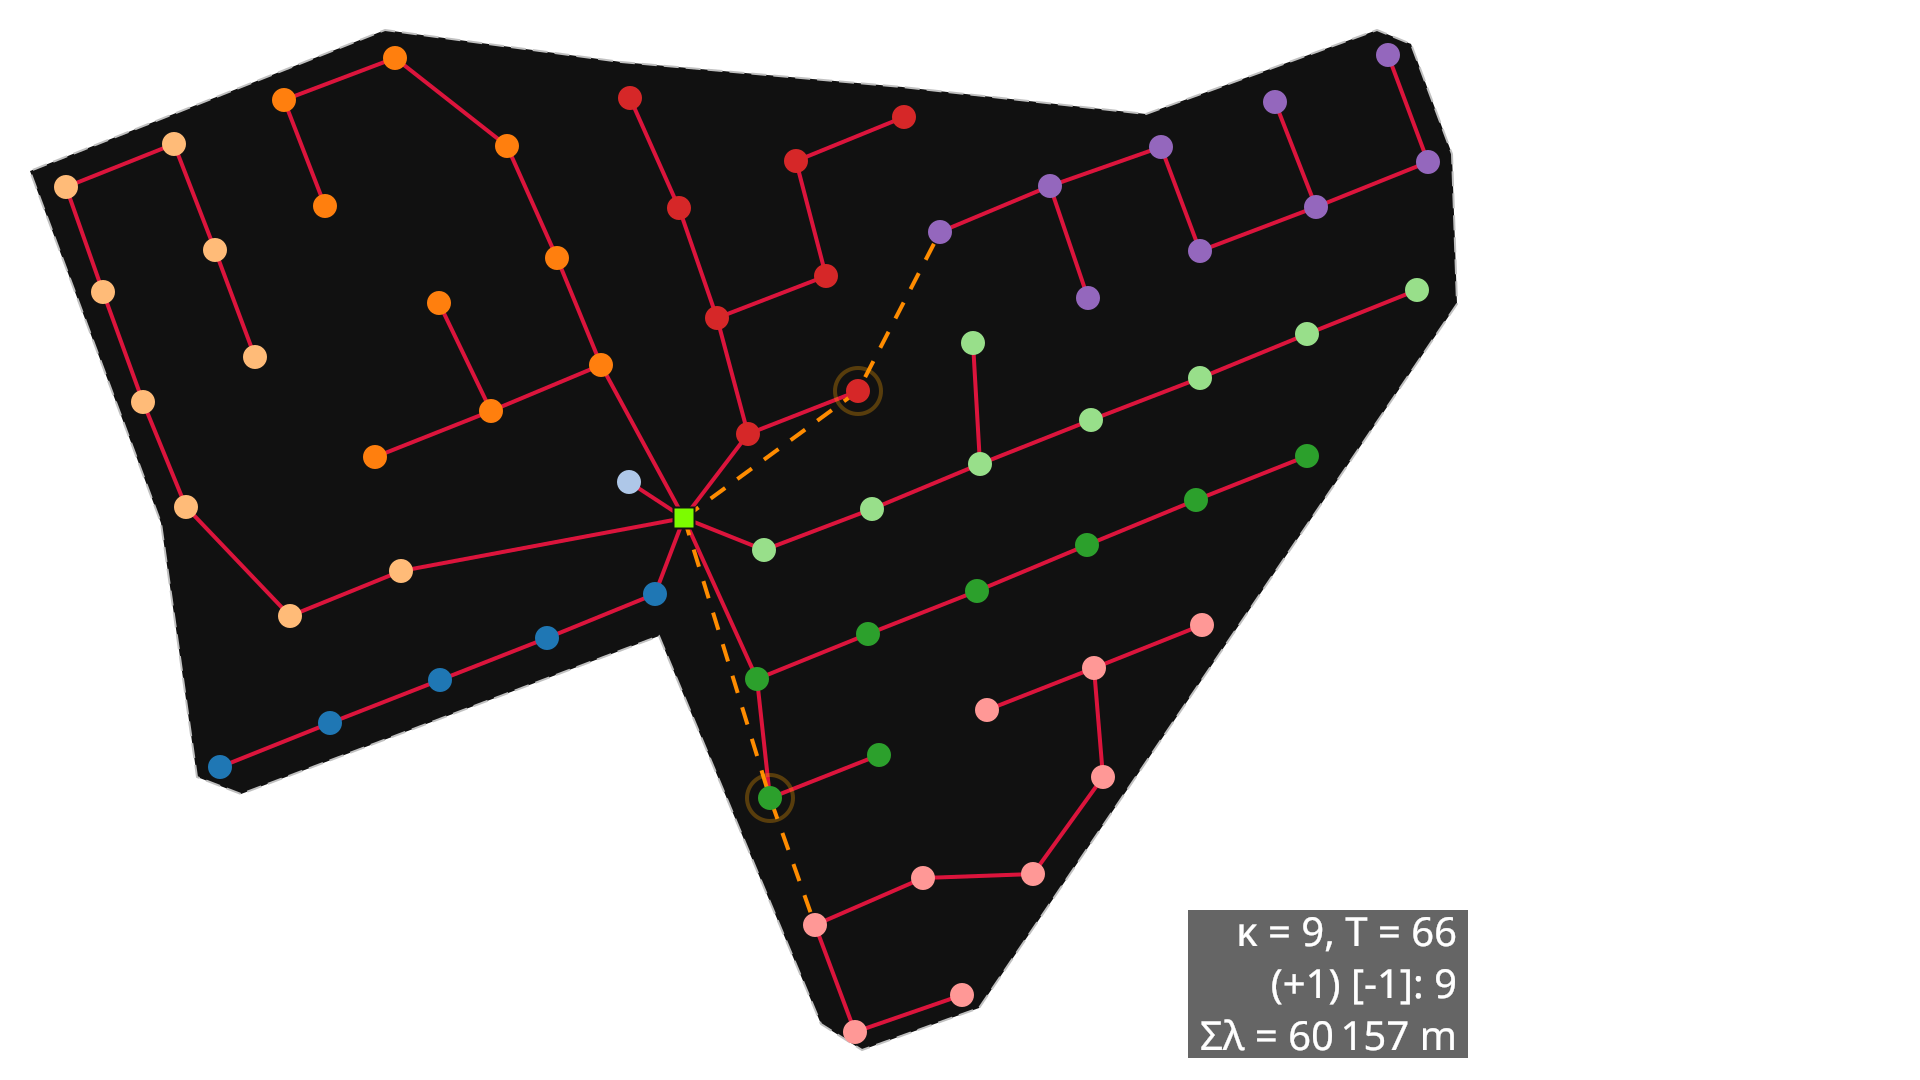

biased_EW (OBEW style)


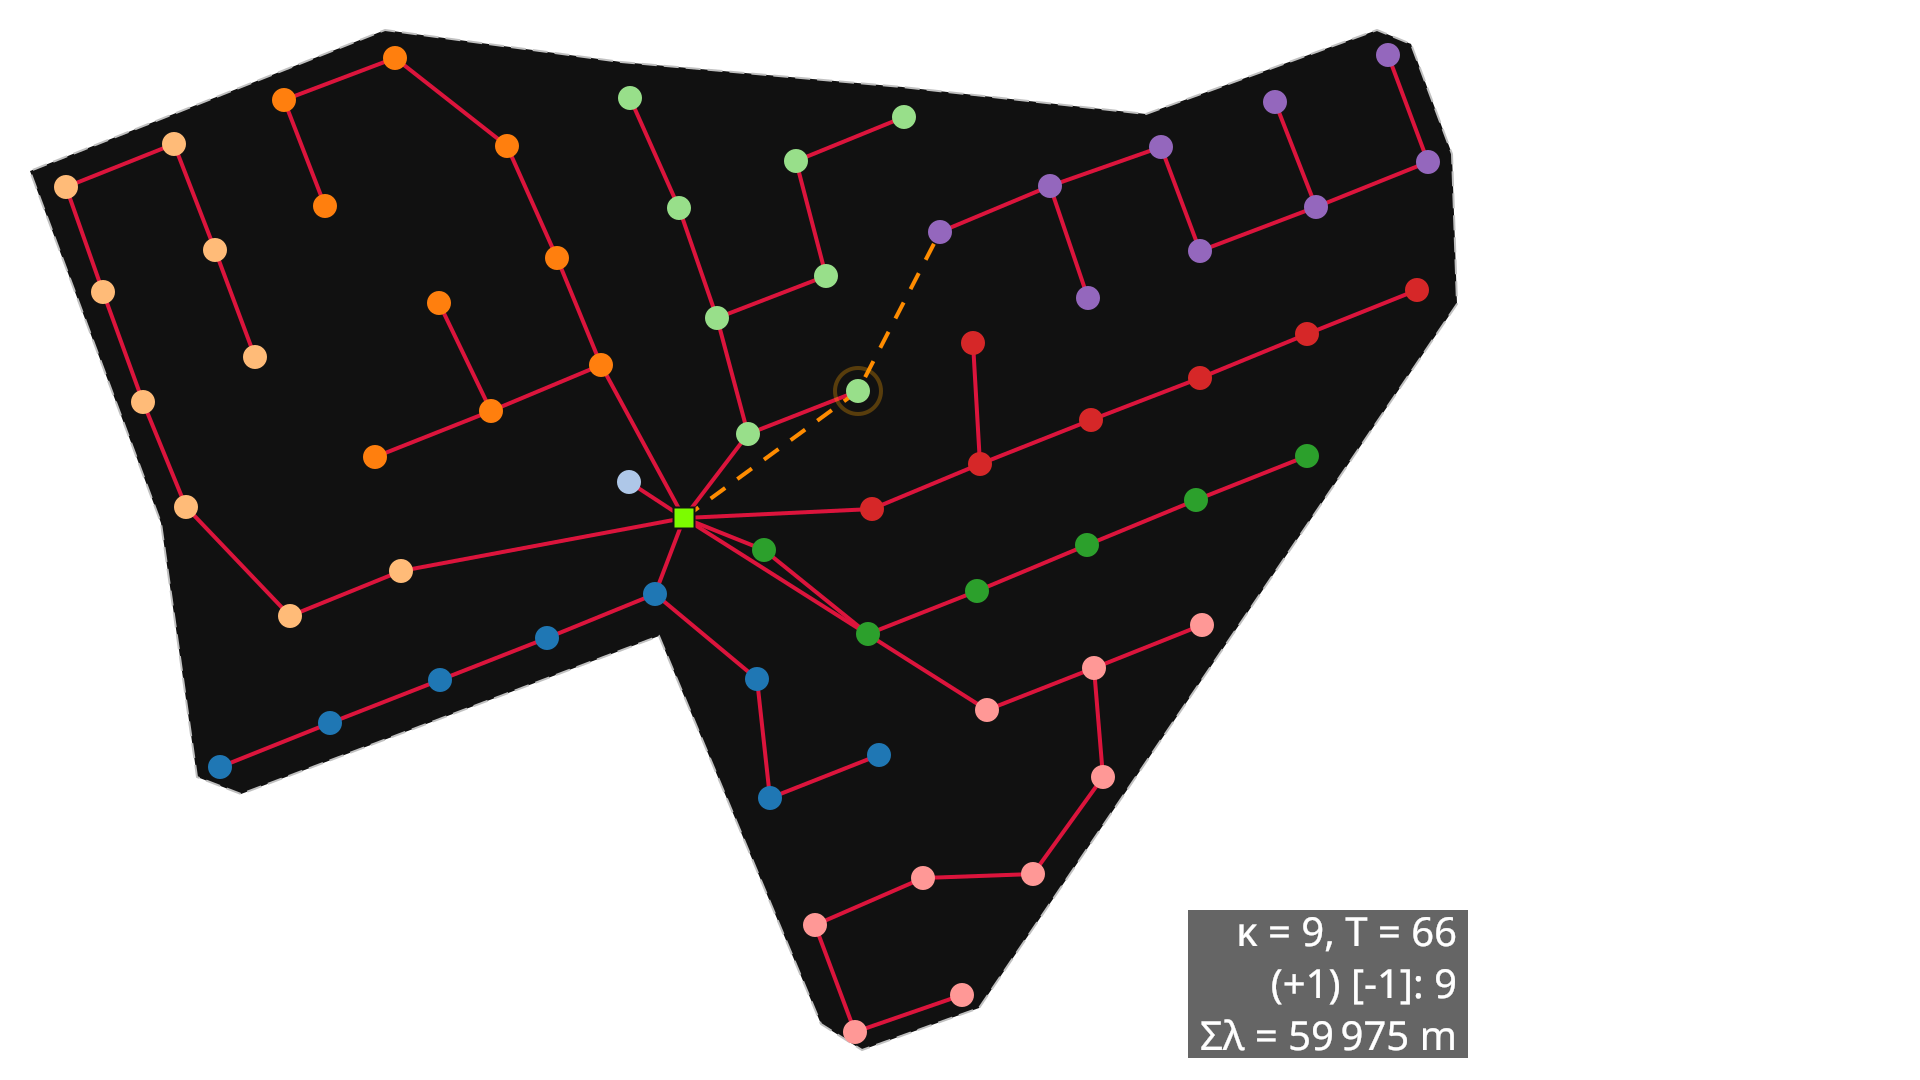

straight feeders (CPEW style)


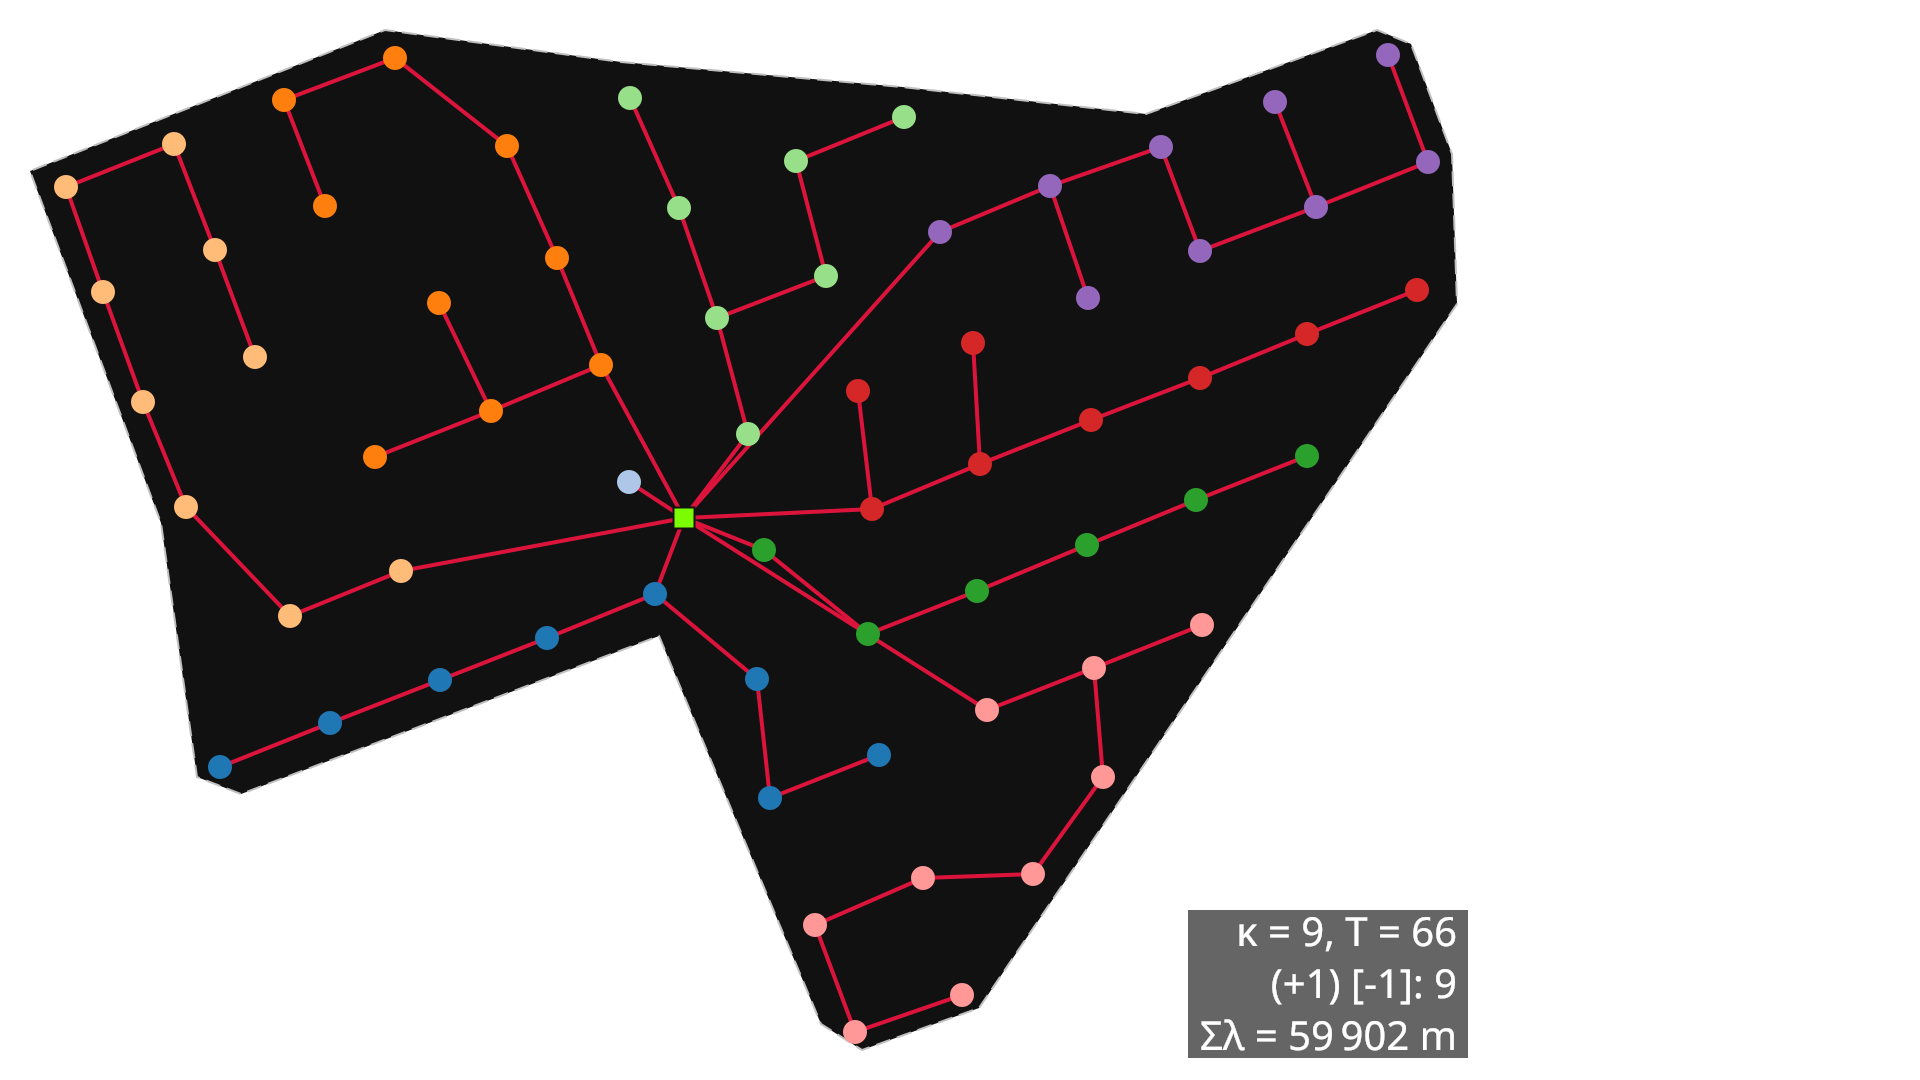

radial (NBEW style)


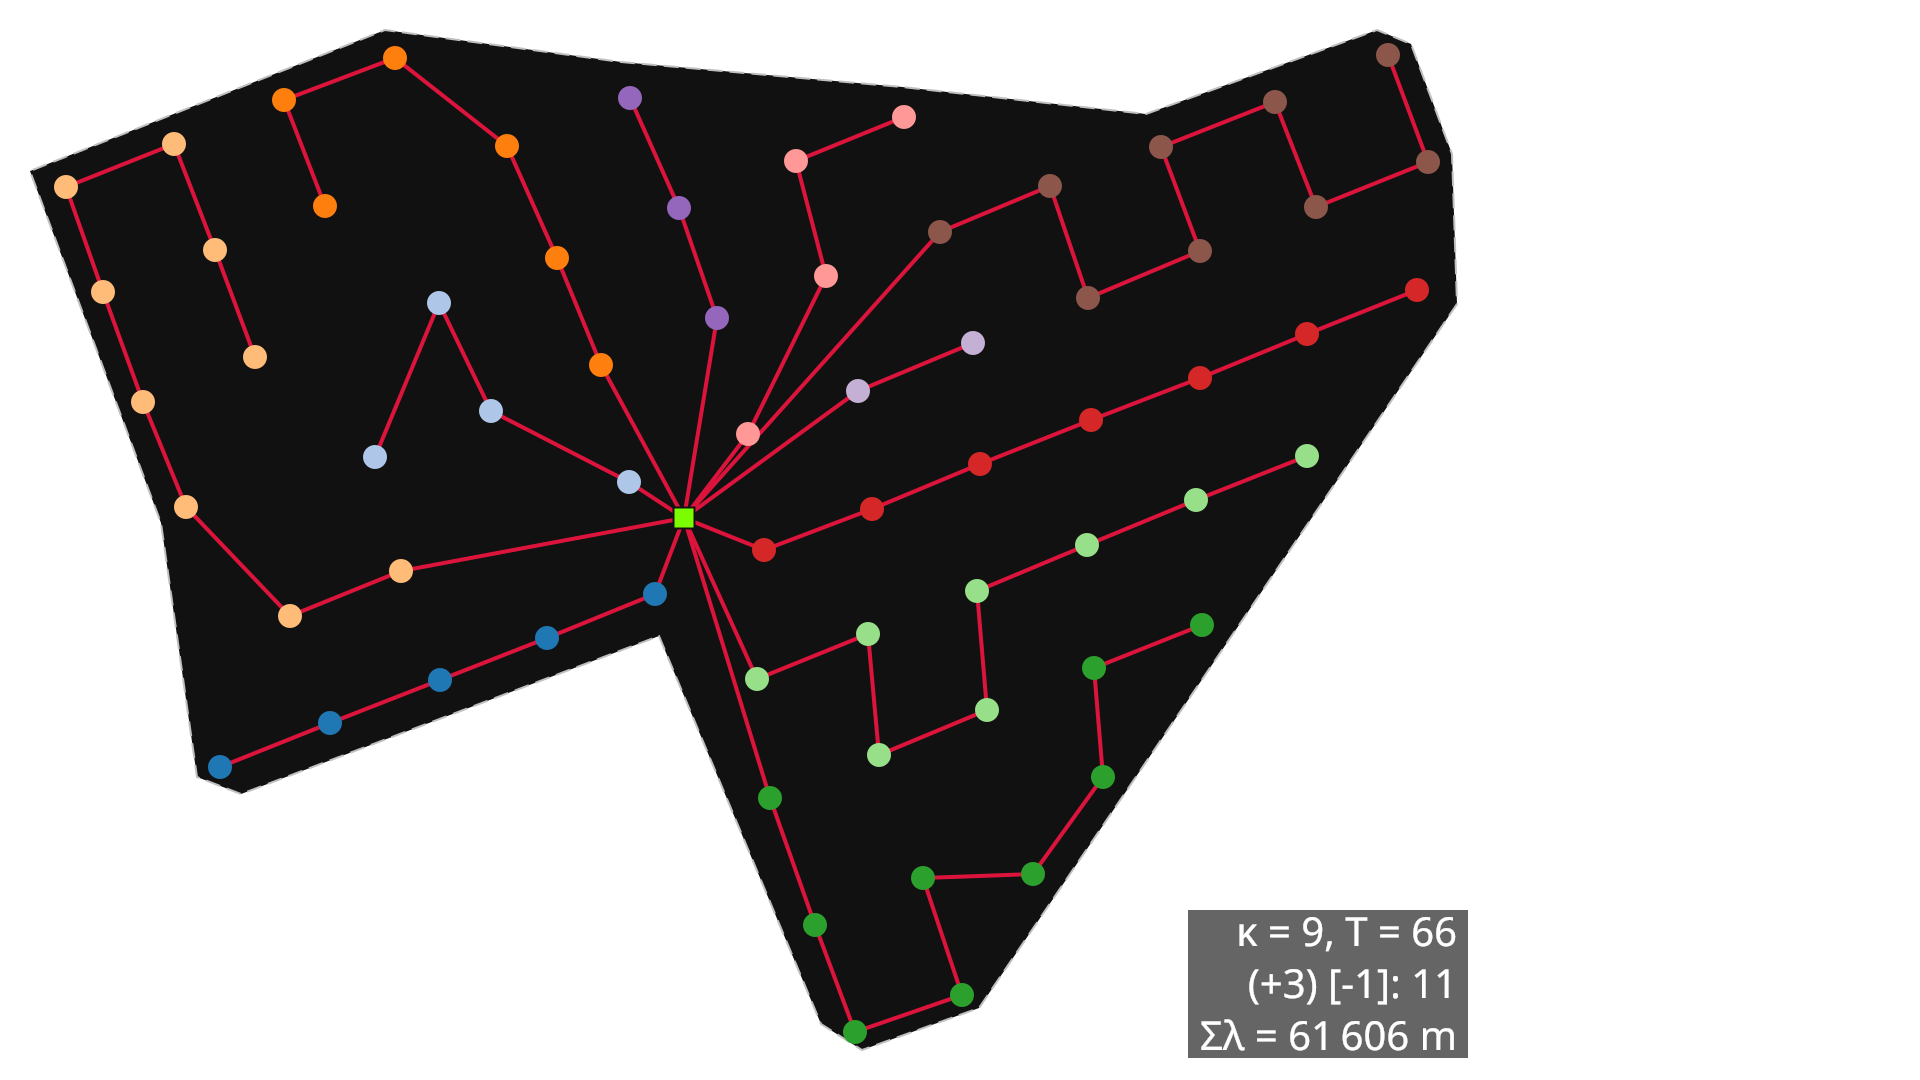

radial (segmented feeders)


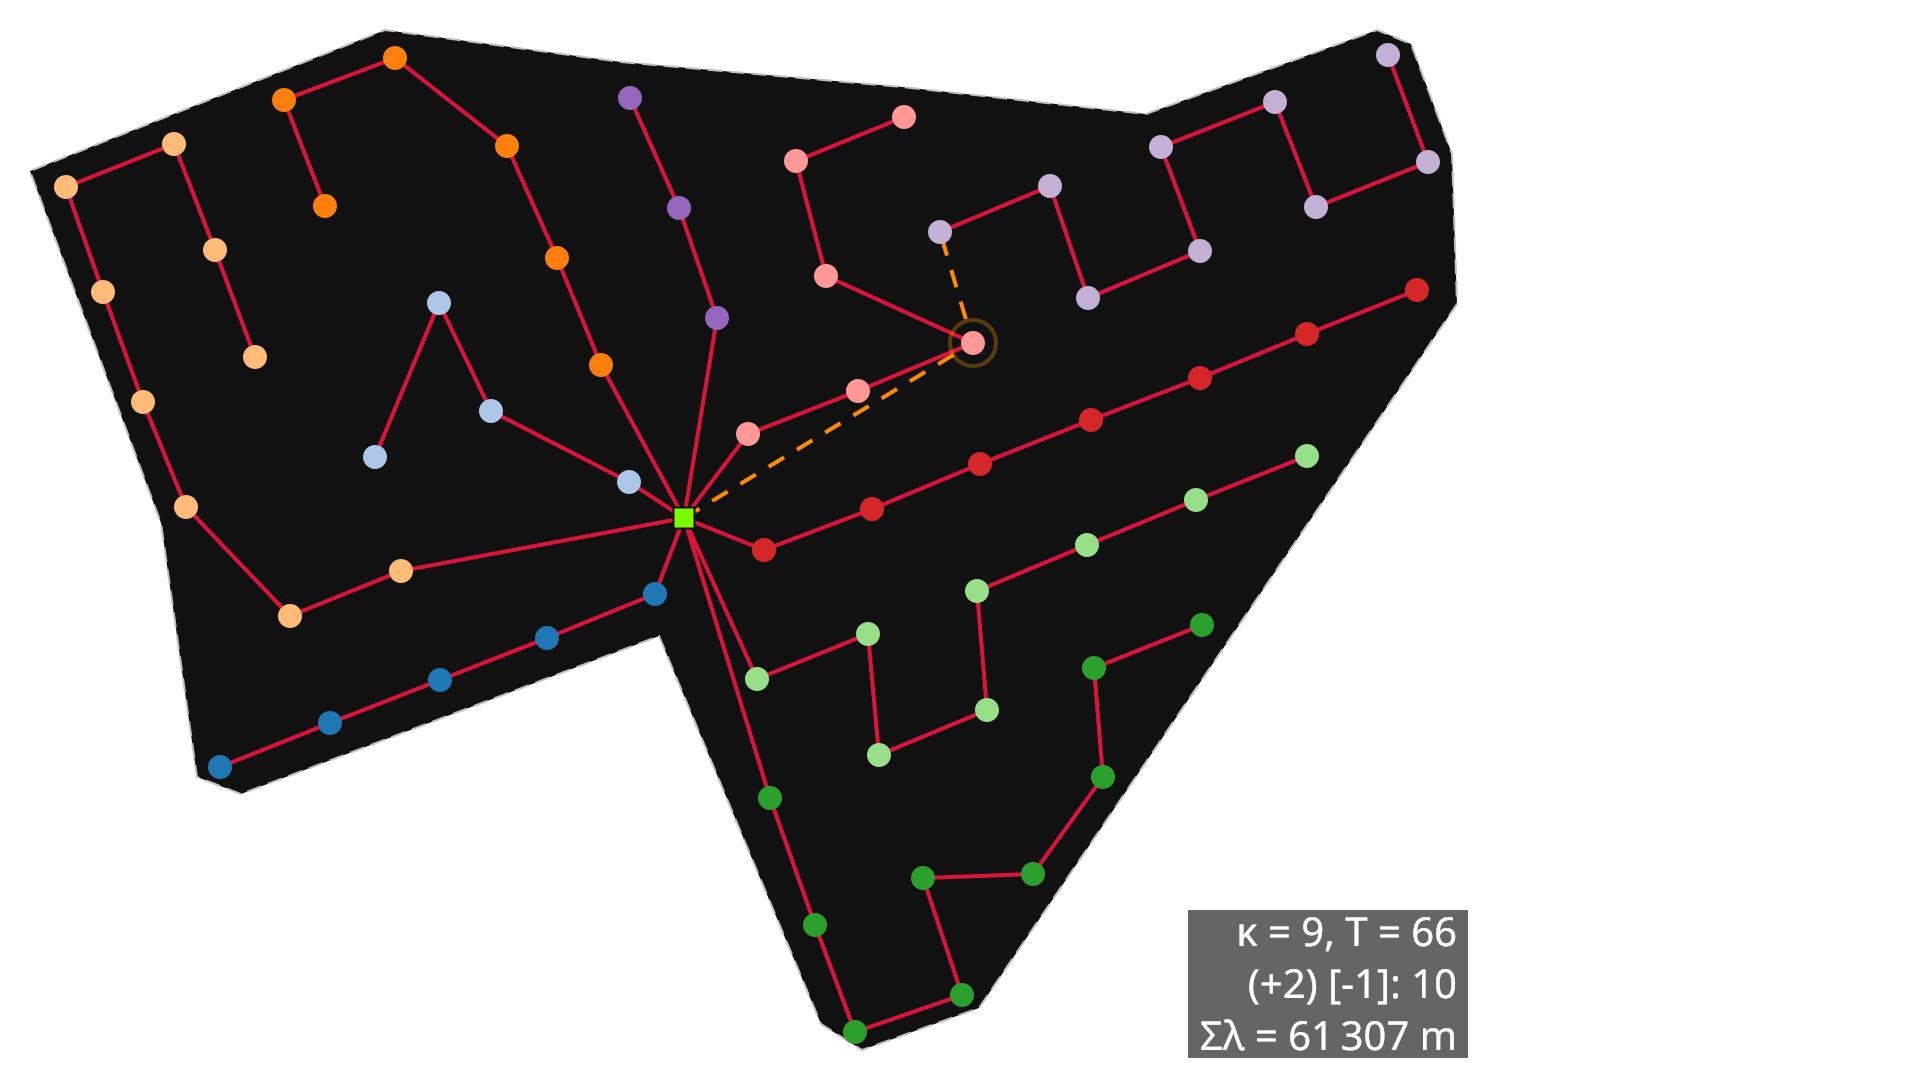

ringed (closed loops)


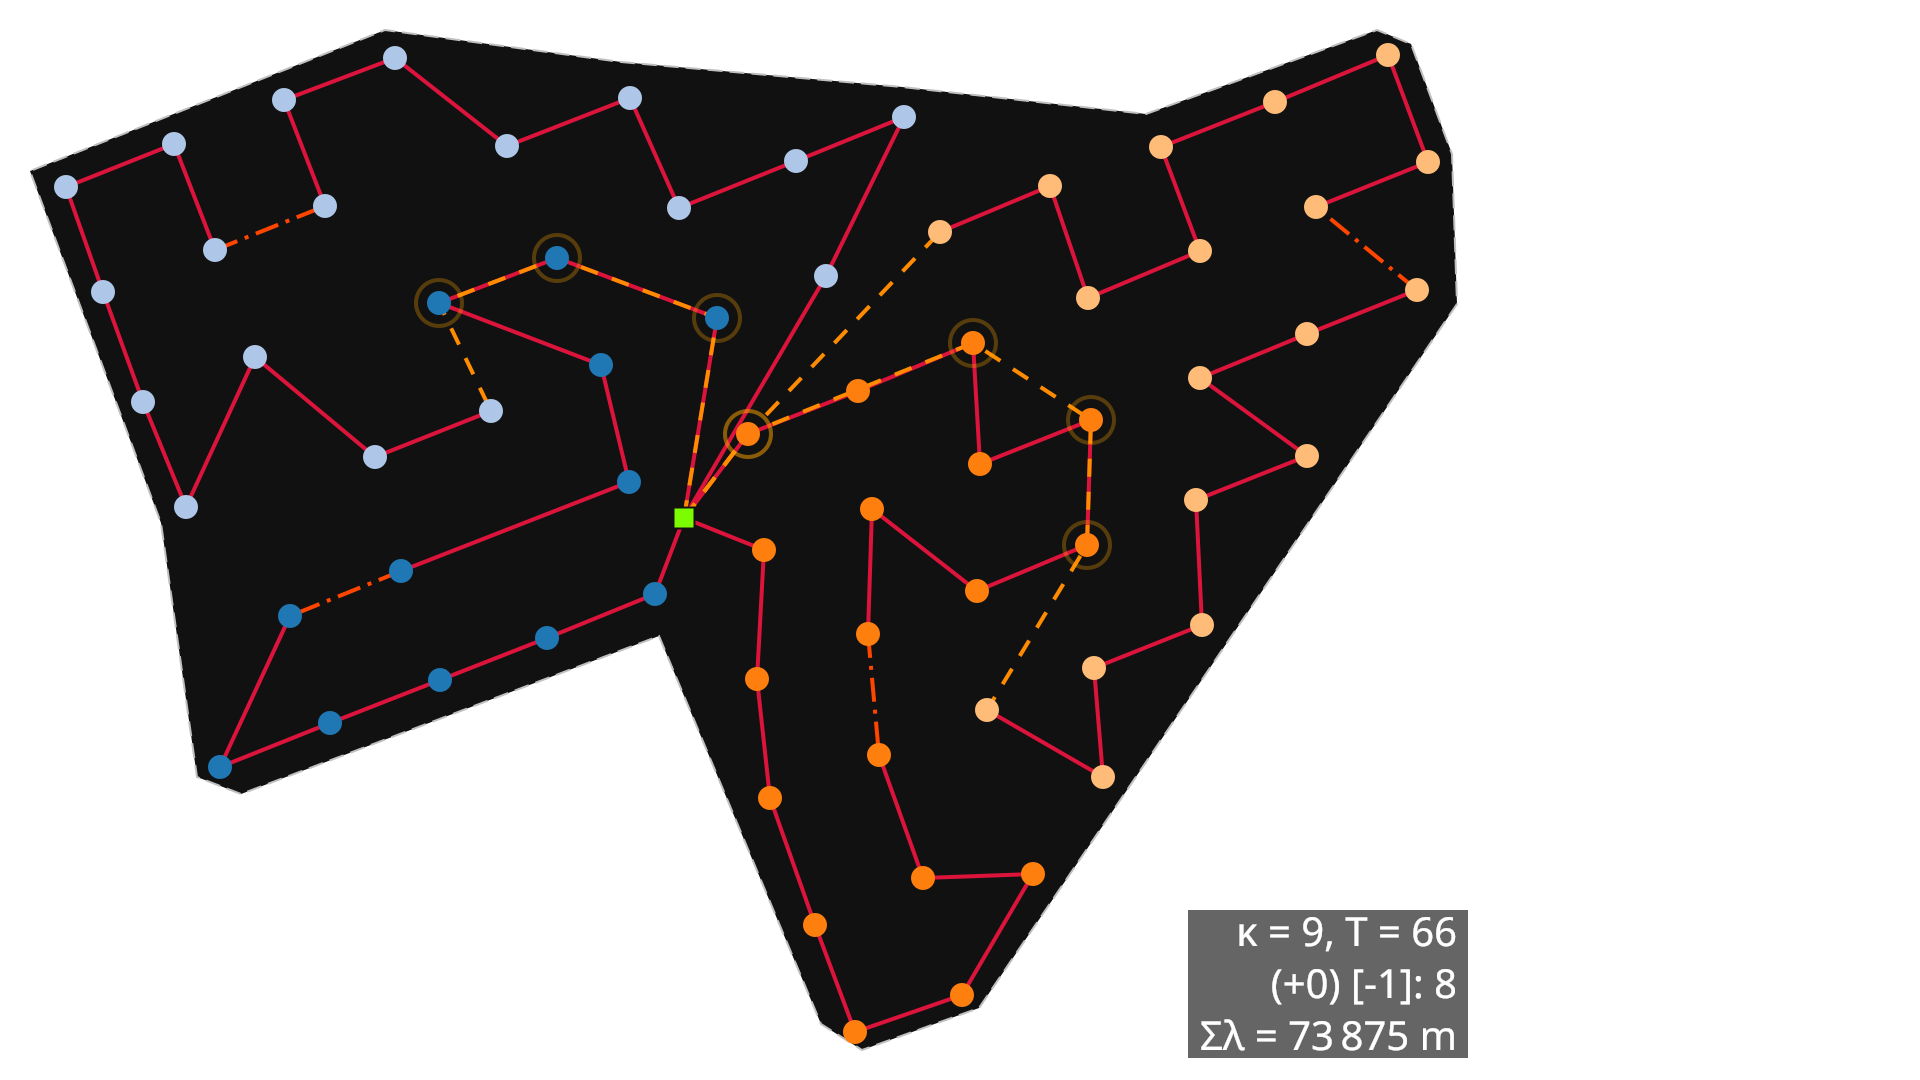

In [9]:
for label, G in solutions.items():
    print(label)
    display(svgplot(G))